### Data Generation for Task - I a) + 1 b)
Series LC-Circuit
Parallel LC-Circuit#same (anti)-resonance


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import qmc
import math

# define task
task = 'b'

if task == 'a':
    data_points = 10000
elif task == 'b':
    data_points = 12000

dimensions = 2
l1_bound = (1e-9, 1e-6)
c1_bound = (1e-9, 1e-6)

# lower_bound = [l1_bound[0], c1_bound[0]]
# upper_bound = [l1_bound[1], c1_bound[1]]
lower_bound = [np.log10(l1_bound[0]), np.log10(c1_bound[0])]
upper_bound = [np.log10(l1_bound[1]), np.log10(c1_bound[1])]

sampler = qmc.LatinHypercube(d = dimensions)
samples = sampler.random(data_points)

first_scaled_points = qmc.scale(samples, lower_bound, upper_bound)
scaled_points = np.power(10.0, first_scaled_points[:])

omega = np.ndarray((data_points,))
data_frame = pd.DataFrame(columns= ["L1", "C1", "Omega"])

for ii in range(data_points):
    omega[ii] = 1/math.sqrt(scaled_points[ii, 0]*scaled_points[ii, 1])
    data_frame.loc[-1] = [scaled_points[ii, 0], scaled_points[ii, 1], omega[ii]]
    data_frame.index = data_frame.index + 1
    data_frame = data_frame.sort_index()

data_frame.to_csv(f"task_I_{task:s}.csv",index=False, float_format='%11.6e')

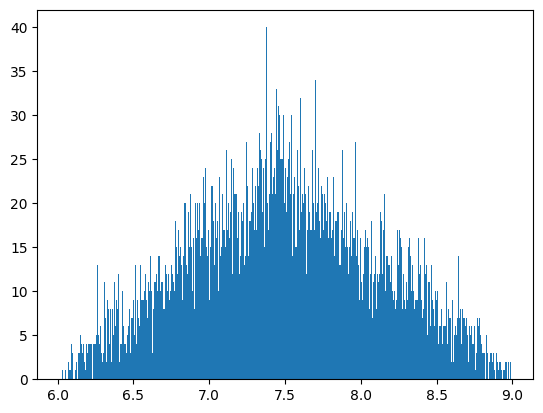

In [3]:
import matplotlib.pyplot as plt
_ = plt.hist(np.log10(omega), 1000)
# plt.xscale('log')


### Data Generation for Task - I c)
Parallel 2 Series RC-Circuit


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import qmc
import math

data_points = 1000000
dimensions = 4
l1_bound = (1e-10, 1e-6)
c1_bound = (1e-10, 1e-6)
l2_bound = (1e-10, 1e-6)
c2_bound = (1e-10, 1e-6)

lower_bound = [l1_bound[0], l2_bound[0], c1_bound[0], c2_bound[0]]
upper_bound = [l1_bound[1], l2_bound[1], c1_bound[1], c2_bound[1]]

sampler = qmc.LatinHypercube(d = dimensions)
samples = sampler.random(data_points)

scaled_points = qmc.scale(samples, lower_bound, upper_bound)

omega_1 = np.ndarray((data_points,))
omega_2 = np.ndarray((data_points,))
omega_3 = np.ndarray((data_points,))
data_frame = pd.DataFrame(columns= ["L1", "L2", "C1", "C2", "Omega_1", "Omega_2", "Omega_3"])


for ii in range(data_points):
    print(ii)
    omega_1[ii] = 1/math.sqrt(scaled_points[ii, 0]*scaled_points[ii, 2])
    omega_2[ii] = math.sqrt((scaled_points[ii, 2]+scaled_points[ii, 3])/((scaled_points[ii, 0]+scaled_points[ii, 1])*(scaled_points[ii, 2]*scaled_points[ii, 3])))
    omega_3[ii] = 1/math.sqrt(scaled_points[ii, 2]*scaled_points[ii, 2])
    data_frame.loc[-1] = [scaled_points[ii, 0], scaled_points[ii, 1], scaled_points[ii, 2], scaled_points[ii, 3], omega_1[ii], omega_2[ii], omega_3[ii]]
    data_frame.index = data_frame.index + 1
    data_frame = data_frame.sort_index()

data_frame.to_csv("task_I_c.csv",index=False, float_format='%11.6e')

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import qmc
import math

# define task
task = 'c'

data_points = 30000

dimensions = 4
l1_bound = (1e-9, 1e-6)
c1_bound = (1e-9, 1e-6)
l2_bound = (1e-9, 1e-6)
c2_bound = (1e-9, 1e-6)

# lower_bound = [l1_bound[0], c1_bound[0]]
# upper_bound = [l1_bound[1], c1_bound[1]]
lower_bound = [np.log10(l1_bound[0]), np.log10(l2_bound[0]), np.log10(c1_bound[0]), np.log10(c2_bound[0])]
upper_bound = [np.log10(l1_bound[1]), np.log10(l2_bound[1]), np.log10(c1_bound[1]), np.log10(c2_bound[1])]


sampler = qmc.LatinHypercube(d = dimensions)
samples = sampler.random(data_points)

first_scaled_points = qmc.scale(samples, lower_bound, upper_bound)
scaled_points = np.power(10.0, first_scaled_points[:])

omega = np.ndarray((data_points,))
data_frame = pd.DataFrame(columns= ["L1", "C1", "Omega"])

for ii in range(data_points):
    omega[ii] = 1/math.sqrt(scaled_points[ii, 0]*scaled_points[ii, 1])
    data_frame.loc[-1] = [scaled_points[ii, 0], scaled_points[ii, 1], omega[ii]]
    data_frame.index = data_frame.index + 1
    data_frame = data_frame.sort_index()

data_frame.to_csv(f"task_I_{task:s}.csv",index=False, float_format='%11.6e')